In [1]:
from raprock.neoscan import get_objects

Let's fetch some active object:

In [2]:
objects = get_objects()
print(f"The first ten objects are:\n\n{', '.join(objects[:20])}")

The first ten objects are:

MOK0002, ZTF10CE, MDQH027, C1CJ1E5, SS26D01, 6CC3621, CEC6JD2, 6CB3B21, oDM0553, CE8AMJ2, C1CC4M5, C19RNP5, C460CH1, A11yQ1b, CEC2XQ2, C1CNHF5, C45ZWM1, P12mi6y, MHM1292, 6CA4G21


Now query for topocentrical ephemerides at LBT observatory.

In [49]:
from raprock.neoscan import get_ephemeris
from raprock.observatories import LBT, VST, TANDEM


OBJ = "CEC2XQ2"
df = get_ephemeris(
    object_name=OBJ,
    observatory=LBT,
    tstart="2026-03-12T18:00",
    tend="2026-03-16T18:00",
    deltat=15, # minutes
)

In [50]:
df.columns

Index(['Object', 'Obs_name', 'Obs_code', 'Mag', 'Alt', 'Azi', 'Airmass',
       'Sun_elev', 'SolEl', 'LunEl', 'LunPh', 'Phase', 'Glat', 'Glon', 'R',
       'Delta', 'RA_deg', 'DEC_deg', 'MJD', 'RA_rate_deg', 'DEC_rate_deg',
       'Vel_deg'],
      dtype='str')

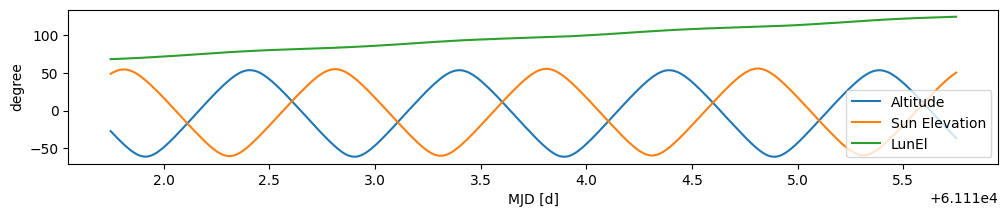

In [51]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 2))
plt.plot(df["MJD"], df["Alt"], label="Altitude")
plt.plot(df["MJD"], df["Sun_elev"], label="Sun Elevation")
plt.plot(df["MJD"], df["LunEl"], label="LunEl")
plt.xlabel("MJD [d]"); plt.ylabel("degree"); plt.legend(loc=4)
plt.show()


# Finding opportunity windows for observations

We will require:
1. the sun to have set (according to the astronomical definition of twilight).
2. the object to be higher than a threshold altitude at observatory.
3. enough time for exposure.

Given these, we find the opportunity windows for starting an object observation.

In [52]:
from raprock.pipes import after_twilight, not_moon_occulted, higher_than, longer_than, opportunity_windows
from raprock.utils import TWILIGHTS

PHASE = "nautical"
MINH = 25 # degrees
EXPOSURE_LEN = 100 # minutes
_df = (df
    .pipe(after_twilight, phase=PHASE)
    .pipe(not_moon_occulted)
    .pipe(higher_than, deg=MINH)
    .pipe(longer_than, duration_min=EXPOSURE_LEN)
)
windows_df = opportunity_windows(_df, EXPOSURE_LEN)

In [53]:
windows_df

,Object,Obs_name,Obs_code,win_start,win_end,Alt_max,V_min,V_delta
0,CEC2XQ2,LBT,G83,61112.260417,61112.451389,53.4,19.6,0.1
1,CEC2XQ2,LBT,G83,61113.250000,61113.451389,53.3,20.0,0.1
2,CEC2XQ2,LBT,G83,61114.239583,61114.451389,53.3,20.3,0.1
3,CEC2XQ2,LBT,G83,61115.239583,61115.451389,53.3,20.6,0.1


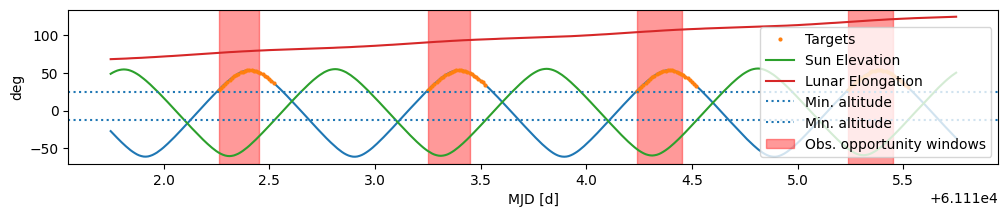

In [42]:
import matplotlib.pyplot as plt


plt.figure(figsize=(12, 2))
plt.plot(df["MJD"], df["Alt"],)
plt.plot(_df["MJD"], _df["Alt"], "o", ms=2, label="Targets")
plt.plot(df["MJD"], df["Sun_elev"], label="Sun Elevation")
plt.plot(df["MJD"], df["LunEl"], label="Lunar Elongation")
plt.axhline(MINH, linestyle="dotted", label="Min. altitude")
plt.axhline(TWILIGHTS[PHASE], linestyle="dotted", label="Min. altitude")
label_set = False
for s, e in windows_df[["win_start", "win_end"]].values:
    plt.axvspan(s, e, label="Obs. opportunity windows" if not label_set else "", color="red", alpha=0.4)
    label_set = True
plt.xlabel("MJD [d]"); plt.ylabel("deg"); plt.legend(loc=4)
plt.show()

# Multiple observatories

In [59]:
import pandas as pd

from raprock.observatories import LBT, VST, TANDEM, CASSINI

EXPOSURE_LEN = 100 # minutes


dfs = {
    obs: get_ephemeris(
        object_name=OBJ,
        observatory=obs,
        tstart="2026-03-12T18:00",
        tend="2026-03-16T18:00",
        deltat=15, # minutes
    ) for obs in [LBT, VST, TANDEM, CASSINI] 
}

def filter_pipe(df):
    return (df
        .pipe(after_twilight, phase=PHASE)
        .pipe(not_moon_occulted)
        .pipe(higher_than, deg=MINH)
        .pipe(longer_than, duration_min=EXPOSURE_LEN)
    )

windows = pd.concat([opportunity_windows(filter_pipe(d), EXPOSURE_LEN) for d in dfs.values()])
windows

,Object,Obs_name,Obs_code,win_start,win_end,Alt_max,V_min,V_delta
0,CEC2XQ2,LBT,G83,61112.260417,61112.451389,53.4,19.6,0.1
1,CEC2XQ2,LBT,G83,61113.250000,61113.451389,53.3,20.0,0.1
2,CEC2XQ2,LBT,G83,61114.239583,61114.451389,53.3,20.3,0.1
3,CEC2XQ2,LBT,G83,61115.239583,61115.451389,53.3,20.6,0.1
0,CEC2XQ2,VST,309,61112.125000,61112.336806,69.0,19.5,0.1
1,CEC2XQ2,VST,309,61113.114583,61113.336806,69.1,19.9,0.1
2,CEC2XQ2,VST,309,61114.114583,61114.336806,69.2,20.3,0.0
3,CEC2XQ2,VST,309,61115.104167,61115.336806,69.2,20.6,0.0
0,CEC2XQ2,TANDEM,D98,61111.947917,61112.107639,41.8,19.4,0.1
1,CEC2XQ2,TANDEM,D98,61112.937500,61113.107639,41.8,19.9,0.0


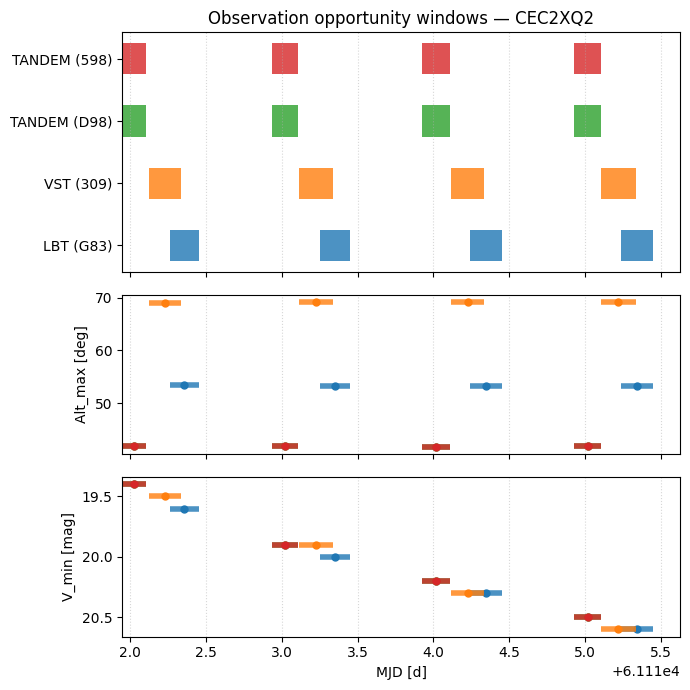

In [61]:
fig, axes = plt.subplots(3, 1, figsize=(7, 7), sharex=True, height_ratios=[3, 2, 2])

labels = (windows["Obs_name"] + " (" + windows["Obs_code"] + ")").unique()
y_pos = {label: i for i, label in enumerate(labels)}
colors = plt.cm.tab10.colors

for _, row in windows.iterrows():
    label = f"{row['Obs_name']} ({row['Obs_code']})"
    y = y_pos[label]
    color = colors[y % len(colors)]
    mid = (row["win_start"] + row["win_end"]) / 2
    width = row["win_end"] - row["win_start"]

    axes[0].barh(y, width, left=row["win_start"], color=color, alpha=0.8, height=0.5)
    axes[1].hlines(row["Alt_max"], row["win_start"], row["win_end"], colors=color, linewidth=4, alpha=0.8)
    axes[1].plot(mid, row["Alt_max"], "o", color=color, ms=5)
    axes[2].hlines(row["V_min"], row["win_start"], row["win_end"], colors=color, linewidth=4, alpha=0.8)
    axes[2].plot(mid, row["V_min"], "o", color=color, ms=5)

axes[0].set_yticks(range(len(labels)))
axes[0].set_yticklabels(labels)
axes[1].set_ylabel("Alt_max [dteg]")
axes[2].set_ylabel("V_min [mag]")
axes[2].invert_yaxis()  # brighter = lower mag = top of axis
axes[2].set_xlabel("MJD [d]")
axes[0].set_title(f"Observation opportunity windows — {OBJ}")

for ax in axes:
    ax.grid(axis="x", linestyle="dotted", alpha=0.5)

plt.tight_layout()
plt.show()